# CRONOS / TFM — Minimal Example

This notebook trains **TFM or CRONOS** on a small synthetic dataset (`DummyTemporalDataset`) to verify your installation and show the basic usage pattern. No real data needed; runs on CPU in under a minute.

In [12]:
import sys, os
# make sure src/ is on the path when running from src/examples/
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))

import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

from data_loaders.data_utils import DummyTemporalDataset
from utils.util_functions import set_seed, get_device

set_seed(42)
device = get_device("cpu")   # change to "cuda" if available
print(f"Using device: {device}")

Using device: cpu


## 1. Build Dummy Dataloaders

`DummyTemporalDataset` generates random 3D sequences — no files needed.

In [ ]:
T, C, D, H, W = 4, 1, 8, 8, 8   # tiny volumes, runs on CPU instantly

train_dataset = DummyTemporalDataset(length=16, T=T, C=C, D=D, H=H, W=W)
val_dataset   = DummyTemporalDataset(length=4,  T=T, C=C, D=D, H=H, W=W)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False)

in_shape = train_dataset._get_data_shape()   # same as train.py does
print("in_shape:", in_shape)

sample = next(iter(train_loader))
print("context shape    :", sample["context"].shape)
print("target_img shape :", sample["target_img"].shape)
print("context_time     :", sample["context_time"])
print("target_time      :", sample["target_time"])

## 2. Build Model

Switch `model_type` between `"tfm"` and `"cronos"` to try both.

In [ ]:
from train import build_model
import argparse

model_type = "tfm"   # or "cronos"

args = argparse.Namespace(
    model_type=model_type,
    base_channels=8,
    fm_model_unet_expands=[1, 1, 1, 1],
    in_shape=in_shape,
    number_evals=5,
    training_noise=0.05,
    device=str(device),
    debug=True,
)

model = build_model(args, device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: {model_type.upper()}  |  parameters: {n_params:,}")

## 3. Train for a Few Epochs

Epoch 1  loss: 0.3109
Epoch 2  loss: 0.2797
Epoch 3  loss: 0.2569


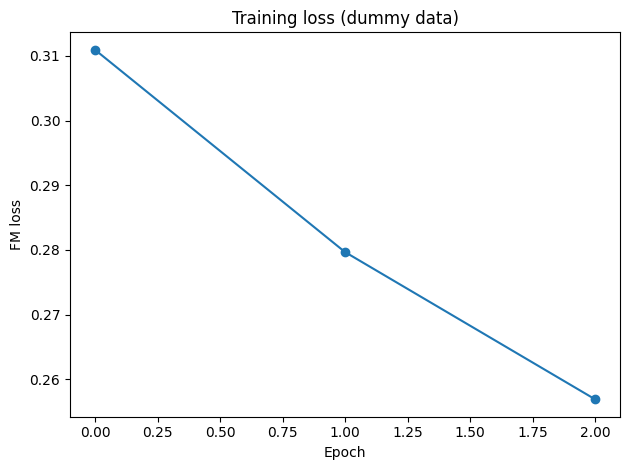

In [15]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
losses = []

for epoch in range(1, 4):
    model.train()
    epoch_loss = 0.0
    for batch in train_loader:
        optimizer.zero_grad()
        loss = model.training_step(batch, batch_idx=0)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_loader)
    losses.append(avg)
    print(f"Epoch {epoch}  loss: {avg:.4f}")

plt.plot(losses, marker="o")
plt.xlabel("Epoch"); plt.ylabel("FM loss"); plt.title("Training loss (dummy data)")
plt.tight_layout(); plt.show()

## 4. Validate and Inspect a Prediction

Run one validation step and visualise a central slice: last context / ground truth / prediction.

In [ ]:
from utils.validation_utils import val_step

val_metrics, val_loss = val_step(
    valid_loader=val_loader,
    train_model=model,
    device=device,
    in_shape=in_shape,
)
print("\nValidation metrics:")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}")

In [ ]:
batch = next(iter(val_loader))
context = batch["context"].to(device)
target  = batch["target_img"].to(device)

model.eval()
with torch.no_grad():
    pred = model.validation_step(context)

def to_slice(t):
    """Squeeze to 2D by taking the central index along every leading dim."""
    t = t.squeeze().cpu().numpy()
    while t.ndim > 2:
        t = t[t.shape[0] // 2]
    t = (t - t.min()) / (t.max() - t.min() + 1e-8)
    return t

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(to_slice(context[0, -1]), cmap="gray"); axes[0].set_title("Last context")
axes[1].imshow(to_slice(target[0]),      cmap="gray"); axes[1].set_title("Ground truth")
axes[2].imshow(to_slice(pred[0]),        cmap="gray"); axes[2].set_title("Prediction")
for ax in axes: ax.axis("off")
plt.suptitle("Central slice, dummy (random) data")
plt.tight_layout(); plt.show()

## 5. Visualize with Utility Functions

Use `visualize_predictions` for a full 2x3 grid (images + residuals),
then render the temporal context sequence plus the final prediction as an inline animation.

In [ ]:
from utils.plotting import visualize_predictions
from utils.validation_utils import get_last_context_image_baseline

batch = next(iter(val_loader))
context_v = batch["context"].to(device)
target_v  = batch["target_img"].to(device)
time_pts  = torch.cat([batch["context_time"], batch["target_time"]], dim=1).to(device)

model.eval()
with torch.no_grad():
    pred_v = model.validation_step(context_v, time_points=time_pts)

# LCI = last non-zero (observed) context frame per sample.
# Context frames are zeroed out where observations are missing, so
# context[:, -1] is often empty. get_last_context_image_baseline finds
# the actual last observation.
lci_v = get_last_context_image_baseline(context_v)   # (B, C, D, H, W)

visualize_predictions(
    context_v, target_v, pred_v, lci=lci_v,
    title="GT / LCI / Prediction (dummy data, central slice)",
)

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

ctx = context_v[0]   # (T, C, D, H, W) -- first sample in the batch

# Find which frame index is the LCI for this sample
flat     = ctx.view(ctx.shape[0], -1)
observed = flat.ne(0).any(dim=-1)                               # (T,) bool
lci_idx  = int((observed.long() * torch.arange(ctx.shape[0])).max())

frames, labels = [], []
for t in range(ctx.shape[0]):
    frames.append(to_slice(ctx[t]))
    tag = "  <-- LCI" if t == lci_idx else ""
    labels.append(f"Context  t={t}{tag}")
frames.append(to_slice(pred_v[0]))
labels.append("Prediction")

fig, ax = plt.subplots(figsize=(4, 4))
ax.axis("off")
im        = ax.imshow(frames[0], cmap="gray", vmin=0, vmax=1)
title_obj = ax.set_title(labels[0], fontsize=12)

def _update(i):
    im.set_data(frames[i])
    title_obj.set_text(labels[i])
    return [im, title_obj]

ani = FuncAnimation(fig, _update, frames=len(frames), interval=500, blit=True)
plt.close(fig)
HTML(ani.to_jshtml())